In [ ]:
# ===== Cell 1: Imports and directories configuration =====

from tqdm.auto import tqdm
from datetime import datetime
from pathlib import Path
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import os

# Import the modular architecture, losses, and dataset from your src/TFT.py
from src.TFT import StockTFT, CustomFocalLoss, MasterStockDataset, initialize_weights

# --- Device & Path Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path("../")
DATA_DIR = PROJECT_ROOT / "data" / "processed_data"
RESULTS_BASE_DIR = PROJECT_ROOT / "results" / "training"

# Ensure results directory exists
RESULTS_BASE_DIR.mkdir(parents=True, exist_ok=True)

print(f" Environment Ready. Using device: {DEVICE}")

# ===== End of cell 1 =====

Define utility functions

In [16]:
# Standard 13 features for the Technical + ER Cube
FEATURE_NAMES = [
    'Gap', 'UWick', 'LWick', 'Body', 'LocalVolZ', 'GlobalVolScale',
    'DOW_sin', 'DOW_cos', 'Month_sin', 'Month_cos', 'DOM_sin', 'DOM_cos', 'ER_Flag'
]

def get_dist_str(labels):
    """Returns a formatted string of the label distribution [Sell/Neutral/Buy]."""
    counts = np.bincount(labels, minlength=3)
    total = max(counts.sum(), 1)
    d = counts / total
    return f"[{d[0]:.1%}/{d[1]:.1%}/{d[2]:.1%}]"

def save_parameter_log(path, run_name, config, final_stats=None):
    """Saves the run's metadata and final results to a text file."""
    with open(path, "w") as f:
        f.write(f"RUN NAME: {run_name}\n")
        f.write(f"TIMESTAMP: {datetime.now()}\n")
        f.write("-" * 30 + "\nARCHITECTURE CONFIG\n" + "-" * 30 + "\n")
        for k, v in config.items(): f.write(f"{k}: {v}\n")
        if final_stats:
            f.write("-" * 30 + "\nFINAL TEST RESULTS\n" + "-" * 30 + "\n")
            for k, v in final_stats.items(): f.write(f"{k}: {v}\n")

Step 1: Initialize the dataset

In [ ]:
# --- Select Dataset for this Session ---
DATASET_FILE = "technical_ER_dataset.pt" # Change to "technical_ER_news_dataset.pt" for the full fusion dataset
ds_path = DATA_DIR / DATASET_FILE

if not ds_path.exists():
    raise FileNotFoundError(f" Dataset not found at {ds_path}")

# 1. Load the Master Dataset
full_ds = MasterStockDataset(ds_path)
input_dim = full_ds.X.shape[-1]
num_samples = len(full_ds)

# 2. Chronological Partitioning - avoid data leakage of stock's prices
train_end = int(num_samples * 0.70)
val_end = int(num_samples * 0.85)

train_indices = range(0, train_end)
val_indices = range(train_end, val_end)
test_indices = range(val_end, num_samples)

train_ds = Subset(full_ds, train_indices)
val_ds   = Subset(full_ds, val_indices)
test_ds  = Subset(full_ds, test_indices)

# 3. Create DataLoaders
BATCH_SIZE = 128
loaders = {
    'tr': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True), # Shuffle ONLY training
    'v':  DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False),
    'ts': DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
}

# 4. Distribution Audit
def print_dist(subset, name):
    labels = [subset.dataset.y[i].item() for i in subset.indices]
    counts = np.bincount(labels, minlength=3)
    total = len(labels)
    dist = counts / total
    print(f" {name:<10} | Size: {total:<6} | Dist [S/N/B]: [{dist[0]:.1%}/{dist[1]:.1%}/{dist[2]:.1%}]")

print(f" Dataset: {DATASET_FILE} | Features: {input_dim}")
print("-" * 60)
print_dist(train_ds, "TRAIN")
print_dist(val_ds,   "VAL")
print_dist(test_ds,  "TEST")
print("-" * 60)

Step 2: Choose training configuration and train the model

In [ ]:
# --- Training Configuration ---
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")
TRAIN_CONFIG = {
    'epochs': 6,
    'lr': 1e-4,
    'patience': 15,
    'use_patience': True,
    'hidden_dim': 64,    # Modular width
    'num_layers': 1,     # Modular depth
    'n_heads': 8,
    'gamma': 1.6,        # Focal parameter
    'dir_weight': 0.6    # Directional penalty weight
}

# Setup Directories
run_name = f"{DATASET_FILE.replace('.pt','')}_{TIMESTAMP}"
run_dir = RESULTS_BASE_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

# Initialize Model & Metrics
model = StockTFT(
    input_dim=input_dim,
    hidden_dim=TRAIN_CONFIG['hidden_dim'],
    num_layers=TRAIN_CONFIG['num_layers']
).to(DEVICE)
model.apply(initialize_weights)

criterion = CustomFocalLoss(
    alpha=full_ds.get_class_weights().to(DEVICE),
    gamma=TRAIN_CONFIG['gamma'],
    dir_weight=TRAIN_CONFIG['dir_weight']
)
optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CONFIG['lr'], weight_decay=1e-4)

# --- Training Loop ---
history = {'tr_l':[], 'v_l':[], 'tr_acc':[], 'v_acc':[], 'feat_imp': []}
best_v_acc, patience_counter = 0.0, 0

print(f" Run: {run_name}\n")

for epoch in range(1, TRAIN_CONFIG['epochs'] + 1):
    model.train()
    tr_l, tr_corr, tr_tot = 0, 0, 0

    pbar = tqdm(enumerate(loaders['tr']),
                total=len(loaders['tr']),
                desc=f"Ep {epoch:02d}",
                bar_format='{l_bar}{bar:20}{r_bar}{bar:-10b}')

    for i, (x, sid, y) in pbar:
        x, sid, y = x.to(DEVICE), sid.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x, sid)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_l += loss.item()
        tr_corr += (out.argmax(1) == y).sum().item()
        tr_tot += y.size(0)

        if i % 5 == 0:
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Validation Phase
    model.eval()
    v_l, v_corr, v_tot = 0, 0, 0
    all_p = []
    with torch.no_grad():
        for x, sid, y in loaders['v']:
            x, sid, y = x.to(DEVICE), sid.to(DEVICE), y.to(DEVICE)
            out = model(x, sid)
            v_l += criterion(out, y).item()
            preds = out.argmax(1)
            v_corr += (preds == y).sum().item()
            v_tot += y.size(0)
            all_p.append(preds.cpu().numpy())

    # --- CRITICAL FIX: Append Metrics to History ---
    ep_tr_l = tr_l / len(loaders['tr'])
    ep_tr_a = tr_corr / tr_tot
    ep_v_l = v_l / len(loaders['v'])
    ep_v_a = v_corr / v_tot
    p_dist = get_dist_str(np.concatenate(all_p))

    # Store in history lists
    history['tr_l'].append(ep_tr_l)
    history['tr_acc'].append(ep_tr_a)
    history['v_l'].append(ep_v_l)
    history['v_acc'].append(ep_v_a)

    # Track Feature Importance
    imp = model.vsn.last_weights.mean(dim=(0,1)).cpu().numpy().flatten()
    history['feat_imp'].append(imp)

    print(f"Ep {epoch:02d} | Train L: {ep_tr_l:.4f} A: {ep_tr_a:.2%} | Val L: {ep_v_l:.4f} A: {ep_v_a:.2%}")
    print(f"      | Pred Dist: {p_dist} | Top Feature Index: {np.argmax(imp)}")

    # --- CRITICAL FIX: Forced Deep Copy for Saving ---
    # We create a new dict for history to ensure the .pt file serializes the list values correctly
    save_history = {k: list(v) for k, v in history.items()}

    checkpoint = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'history': save_history,
        'config': TRAIN_CONFIG
    }

    # Save State & Checkpoint
    torch.save(checkpoint, run_dir / "latest_checkpoint.pt")

    if ep_v_a > best_v_acc:
        best_v_acc, patience_counter = ep_v_a, 0
        torch.save(checkpoint, run_dir / "best_model.pt")
        print(" New Best Accuracy! Saved.")
    else:
        patience_counter += 1

    if TRAIN_CONFIG['use_patience'] and patience_counter >= TRAIN_CONFIG['patience']:
        print(f" Early stopping at epoch {epoch}")
        break

# =============================================================================
# 4. FINAL TEST EVALUATION (OUT-OF-SAMPLE)
# =============================================================================
print("\n" + "═"*60 + "\n🏁 TRAINING COMPLETE. EVALUATING BEST MODEL ON TEST SET\n" + "═"*60)

# 1. Load the Best Weights
best_ckpt = torch.load(run_dir / "best_model.pt", weights_only=False)
model.load_state_dict(best_ckpt['model_state'])
model.eval()

ts_l_sum, ts_corr, ts_tot = 0, 0, 0
all_p, all_y = [], []

# 2. Final Pass
with torch.no_grad():
    for x, sid, y in loaders['ts']:
        x, sid, y = x.to(DEVICE), sid.to(DEVICE), y.to(DEVICE)

        out = model(x, sid)
        loss = criterion(out, y)

        preds = out.argmax(1)
        ts_l_sum += loss.item()
        ts_corr += (preds == y).sum().item()
        ts_tot += y.size(0)

        all_p.append(preds.cpu().numpy())
        all_y.append(y.cpu().numpy())

# 3. Compute Final Metrics
final_ts_l = ts_l_sum / len(loaders['ts'])
final_ts_a = ts_corr / ts_tot
p_dist = get_dist_str(np.concatenate(all_p))
t_dist = get_dist_str(np.concatenate(all_y))

# 4. Print & Save Final Audit
print(f"FINAL TEST RESULTS for {run_name}:")
print(f"      | Accuracy: {final_ts_a:.2%}")
print(f"      | Loss:     {final_ts_l:.5f}")
print(f"      | Dist:     Pred {p_dist} vs True {t_dist}")

final_stats = {
    "Test Accuracy": f"{final_ts_a:.2%}",
    "Test Loss": f"{final_ts_l:.5f}",
    "Pred Distribution": p_dist,
    "True Distribution": t_dist
}

save_parameter_log(run_dir / "parameter_log.txt", run_name, TRAIN_CONFIG, final_stats)

Step 3: Plot results

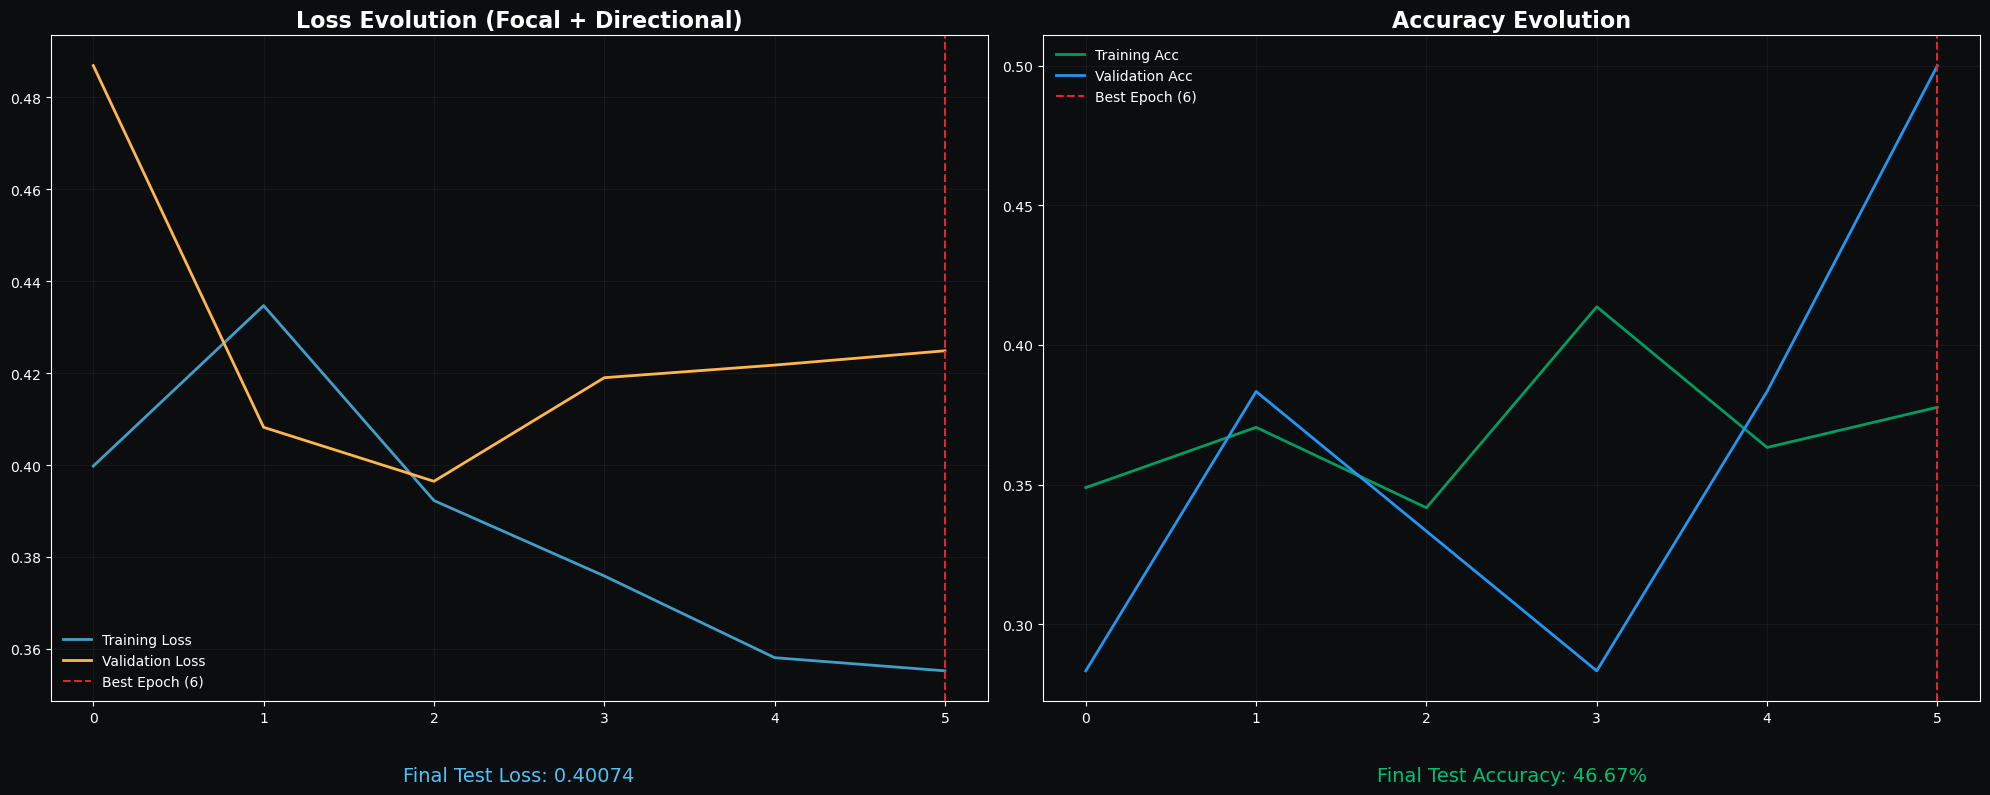

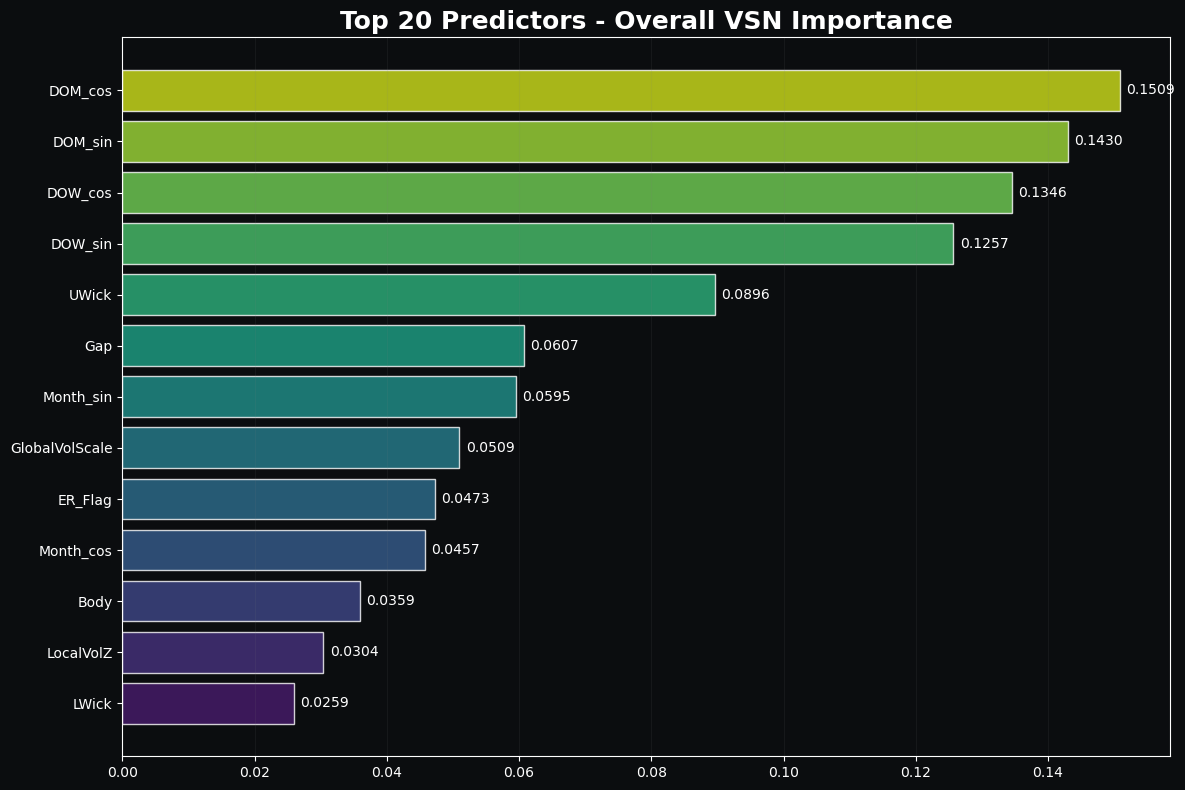

In [ ]:
if 'run_dir' not in locals() or not any((RESULTS_BASE_DIR / run_name).iterdir()):
    all_runs = [d for d in RESULTS_BASE_DIR.iterdir() if d.is_dir()]
    if not all_runs:
        raise FileNotFoundError("❌ No training runs found in results/training/")
    run_dir = max(all_runs, key=os.path.getmtime)
    print(f" Automatically selected latest run: {run_dir.name}")

try:
    checkpoint = torch.load(run_dir / "best_model.pt", weights_only=False)
    h = checkpoint['history']

    if not h['v_acc']:
        raise ValueError(f "The history in {run_dir.name} is empty. Did the run crash at Epoch 0?")

    best_epoch = np.argmax(h['v_acc'])
except Exception as e:
    print(f" Error loading results: {e}")
    checkpoint = torch.load(run_dir / "latest_checkpoint.pt", weights_only=False)
    h = checkpoint['history']
    best_epoch = np.argmax(h['v_acc'])

plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), facecolor='#0b0d0f')

for ax in [ax1, ax2]:
    ax.set_facecolor('#0b0d0f')
    ax.grid(color='gray', alpha=0.1)

# Plot 1: Loss
ax1.plot(h['tr_l'], label='Training Loss', color='#4fc3f7', lw=2, alpha=0.8)
ax1.plot(h['v_l'], label='Validation Loss', color='#ffb74d', lw=2)
ax1.axvline(x=best_epoch, color='#df2928', linestyle='--', lw=1.5, label=f'Best Epoch ({best_epoch+1})')
ax1.set_title("Loss Evolution (Focal + Directional)", fontsize=16, fontweight='bold')
ax1.legend(frameon=False)
if 'final_ts_l' in locals():
    ax1.text(0.5, -0.12, f"Final Test Loss: {final_ts_l:.5f}", transform=ax1.transAxes, ha='center', fontsize=14, color='#4fc3f7')

# Plot 2: Accuracy
ax2.plot(h['tr_acc'], label='Training Acc', color='#00c076', lw=2, alpha=0.8)
ax2.plot(h['v_acc'], label='Validation Acc', color='#2196f3', lw=2)
ax2.axvline(x=best_epoch, color='#df2928', linestyle='--', lw=1.5, label=f'Best Epoch ({best_epoch+1})')
ax2.set_title("Accuracy Evolution", fontsize=16, fontweight='bold')
ax2.legend(frameon=False)
if 'final_ts_a' in locals():
    ax2.text(0.5, -0.12, f"Final Test Accuracy: {final_ts_a:.2%}", transform=ax2.transAxes, ha='center', fontsize=14, color='#00c076')

plt.tight_layout()
plt.show()

# Feature Importance Diagram
plt.figure(figsize=(12, 8), facecolor='#0b0d0f')
ax = plt.gca(); ax.set_facecolor('#0b0d0f')

# Use mean importance across the entire run
overall_imp = np.mean(h['feat_imp'], axis=0)
sorted_idx = np.argsort(overall_imp)

# Generate labels based on index mapping
plot_labels = []
for i in sorted_idx:
    if i < len(FEATURE_NAMES):
        plot_labels.append(FEATURE_NAMES[i])
    else:
        plot_labels.append(f"News_Latent_{i - len(FEATURE_NAMES)}")

# Slice the top 20 for readability
top_n = 20
display_idx = sorted_idx[-top_n:]
display_labels = plot_labels[-top_n:]

colors = sns.color_palette("viridis", len(display_idx))
bars = ax.barh(display_labels, overall_imp[display_idx], color=colors, edgecolor='white', alpha=0.8)
ax.set_title(f"Top {top_n} Predictors - Overall VSN Importance", fontsize=18, fontweight='bold')
ax.grid(axis='x', color='gray', alpha=0.1)

for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.4f}', va='center', color='white')

plt.tight_layout()
plt.show()